In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import time
import matplotlib.pyplot as plt
from pathlib import Path

jax.config.update("jax_enable_x64", True) # Force 64-bit precision

# Simulated sphere
def generate_sphere_points(n_points):
    """Generates roughly uniform points on a unit sphere using a Fibonacci lattice."""
    indices = np.arange(0, n_points, dtype=float) + 0.5
    phi = np.arccos(1 - 2 * indices / n_points)
    theta = np.pi * (1 + 5**0.5) * indices
    
    x = np.cos(theta) * np.sin(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(phi)
    return np.stack([x, y, z], axis=-1)

def simulate_geodesics(n_trajectories, n_steps, dt=0.1):
    """Simulates segments of great circles (geodesics) on a 3D unit sphere."""
    np.random.seed(42)
    
    # Random initial positions
    x0 = np.random.randn(n_trajectories, 3)
    x0 /= np.linalg.norm(x0, axis=-1, keepdims=True)
    
    # Random initial velocities tangent to the sphere
    v0 = np.random.randn(n_trajectories, 3)
    v0 = v0 - np.sum(v0 * x0, axis=-1, keepdims=True) * x0
    v0 /= np.linalg.norm(v0, axis=-1, keepdims=True)
    
    # Exact great circle dynamics: x(t) = x0*cos(t) + v0*sin(t)
    t = np.arange(n_steps) * dt
    t_exp = t[None, :, None]
    
    trajectories = x0[:, None, :] * np.cos(t_exp) + v0[:, None, :] * np.sin(t_exp)
    return trajectories

def generate_neural_activity(trajectories, place_cell_centers, sigma=0.4):
    """Simulates place cell activations based on proximity to the geodesic trajectory."""
    dot_product = np.einsum('tsc,pc->tsp', trajectories, place_cell_centers)
    dist_sq = 2.0 - 2.0 * dot_product
    activity = np.exp(-dist_sq / (2 * sigma**2))
    return activity

# 2. Learn the Manifold. 2D for now to check Kathleen's issues
def init_mlp(keys, layer_sizes):
    """MLP initialization."""
    params = []
    for i in range(len(layer_sizes) - 1):
        W = jax.random.normal(keys[i], (layer_sizes[i], layer_sizes[i+1])) * jnp.sqrt(2.0/layer_sizes[i])
        b = jnp.zeros((layer_sizes[i+1],))
        params.append((W, b))
    return params

def apply_mlp(params, x, final_activation=None):
    """Forward pass for MLP."""
    for W, b in params[:-1]:
        x = jnp.dot(x, W) + b
        x = jax.nn.swish(x)
    W, b = params[-1]
    out = jnp.dot(x, W) + b
    if final_activation == 'sigmoid':
        return jax.nn.sigmoid(out)
    if final_activation == 'softplus':
        return jax.nn.softplus(out)
    return out

def init_model_params(key, n_cells):
    """Initializes parameters for the Encoder, Metric, and Decoder networks."""
    keys = jax.random.split(key, 3)
    
    # Encoder: Maps (Y(0), Y(1)) -> (x0, v0)
    enc_keys = jax.random.split(keys[0], 4)
    enc_params = init_mlp(enc_keys, [n_cells * 2, 128, 128, 4])  
    
    # Decoder: Maps latent x(t) -> Y_hat(t)
    dec_keys = jax.random.split(keys[1], 4)
    dec_params = init_mlp(dec_keys, [2, 128, 128, n_cells])
    
    # Metric Network: Maps x -> g(x)
    metric_keys = jax.random.split(keys[2], 4)
    metric_params = init_mlp(metric_keys, [2, 64, 64, 3])
    
    # This is bad and I should feel bad. Hacky init for diag(1,1) at t=0
    metric_params[-1] = (
        jnp.zeros((64, 3)),
        jnp.array([1.0, 0.0, 0.37]) 
    )
    
    return {'enc': enc_params, 'metric': metric_params, 'dec': dec_params}

def get_metric(metric_params, x):
    """Evaluates the neural metric tensor g(x) to ensure positive-definiteness."""
    L_elems = apply_mlp(metric_params, x)
    L = jnp.array([
        [L_elems[0], 0.0], 
        [L_elems[1], jax.nn.softplus(L_elems[2]) + 0.1]
    ])
    g = L @ L.T + 1e-3 * jnp.eye(2)
    return g

def get_christoffel(metric_params, x):
    """
    Explicitly computes the Christoffel symbols of the second kind 
    using the spatial derivatives of the metric tensor.
    """
    g = get_metric(metric_params, x)
    g_inv = jnp.linalg.inv(g)

    # Compute Jacobian of the metric: dg[i, j, k] = \partial_k g_{ij}
    dg = jax.jacobian(get_metric, argnums=1)(metric_params, x)

    # Transpose so D[k, i, j] = \partial_k g_{ij}
    D = jnp.transpose(dg, (2, 0, 1))

    # Construct the terms for the Christoffel symbols of the first kind:
    # \Gamma_{m i j} = 1/2 * ( \partial_i g_{mj} + \partial_j g_{mi} - \partial_m g_{ij} )
    # Using explicit einsum mappings to avoid transpose errors:
    term1 = jnp.einsum('imj->mij', D) # \partial_i g_{mj}
    term2 = jnp.einsum('jmi->mij', D) # \partial_j g_{mi}
    term3 = jnp.einsum('mij->mij', D) # \partial_m g_{ij}

    Gamma_first = 0.5 * (term1 + term2 - term3)

    # Raise the index: Gamma^m_{ij} = g^{mk} \Gamma_{kij}
    Gamma = jnp.einsum('mk,kij->mij', g_inv, Gamma_first)
    return Gamma

def geodesic_equation(x, v, metric_params):
    r"""Evaluates the geodesic equation: \ddot{x}^m = - \Gamma^m_{ij} \dot{x}^i \dot{x}^j"""
    Gamma = get_christoffel(metric_params, x)
    dv_dt = -jnp.einsum('mij,i,j->m', Gamma, v, v)
    return dv_dt

def rk4_step(x, v, dt, metric_params):
    """Runge-Kutta 4 Integrator for the explicit geodesic equation."""
    def f(state):
        _x, _v = state
        dx_dt = _v
        dv_dt = geodesic_equation(_x, _v, metric_params)
        return dx_dt, dv_dt
        
    k1_x, k1_v = f((x, v))
    k2_x, k2_v = f((x + 0.5*dt*k1_x, v + 0.5*dt*k1_v))
    k3_x, k3_v = f((x + 0.5*dt*k2_x, v + 0.5*dt*k2_v))
    k4_x, k4_v = f((x + dt*k3_x, v + dt*k3_v))
    
    x_next = x + (dt / 6.0) * (k1_x + 2*k2_x + 2*k3_x + k4_x)
    v_next = v + (dt / 6.0) * (k1_v + 2*k2_v + 2*k3_v + k4_v)
    return x_next, v_next

def integrate_geodesic(x0, v0, n_steps, dt, metric_params):
    """Evolve latent trajectory using jax.lax.scan for high efficiency."""
    def step_fn(state, _):
        x, v = state
        x_next, v_next = rk4_step(x, v, dt, metric_params)
        return (x_next, v_next), x_next
    
    _, x_traj_rest = jax.lax.scan(step_fn, (x0, v0), None, length=n_steps-1)
    return jnp.concatenate([x0[None, :], x_traj_rest], axis=0)

def model_forward(params, y_seq, dt):
    """Forward pass mapping Y(t) -> Latent Flow -> Y_hat(t)"""
    # 1. Encode using the first two frames to capture initial velocity
    y_in = jnp.concatenate([y_seq[0], y_seq[1]], axis=-1)
    latent_init = apply_mlp(params['enc'], y_in)
    x0, v0 = latent_init[:2], latent_init[2:]
    
    # 2. Simulate explicit latent geodesic
    n_steps = y_seq.shape[0]
    x_traj = integrate_geodesic(x0, v0, n_steps, dt, params['metric'])
    
    # 3. Decode back to neural space
    y_hat = jax.vmap(apply_mlp, in_axes=(None, 0, None))(
        params['dec'], x_traj, 'softplus'
    )
    return y_hat

@jax.jit
def batch_loss_fn(params, y_batch, dt):
    """Mean Squared Error across a batch of trajectories."""
    losses = jax.vmap(lambda p, y: jnp.mean((y - model_forward(p, y, dt))**2), 
                      in_axes=(None, 0))(params, y_batch)
    return jnp.mean(losses)

def plot_test_reconstruction(params, test_trajectory, test_activity, place_cells, dt):
    """Plots the true vs reconstructed 3D geodesic on the sphere."""
    recon_activity = model_forward(params, test_activity, dt)
    recon_activity = np.array(recon_activity)
    
    recon_3d = np.dot(recon_activity, place_cells)
    recon_3d = recon_3d / np.linalg.norm(recon_3d, axis=-1, keepdims=True)
    
    fig = plt.figure(figsize=(18, 6))
    
    # Panel 1: 3D Sphere and Trajectories
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:20j]
    x = np.cos(u)*np.sin(v)
    y = np.sin(u)*np.sin(v)
    z = np.cos(v)
    ax1.plot_wireframe(x, y, z, color='gray', alpha=0.15)
    
    ax1.plot(test_trajectory[:, 0], test_trajectory[:, 1], test_trajectory[:, 2], 
             label='True Geodesic', color='blue', linewidth=2.5, marker='o', markersize=4)
    ax1.plot(recon_3d[:, 0], recon_3d[:, 1], recon_3d[:, 2], 
             label='Reconstructed Geodesic', color='red', linestyle='--', linewidth=2.5, marker='x')
    
    ax1.set_title("3D Sphere Representation", fontsize=14)
    ax1.legend(loc='upper right')
    ax1.set_axis_off() 

    # Panel 2: Original Neural Activity
    ax2 = fig.add_subplot(1, 3, 2)
    im2 = ax2.imshow(test_activity.T, aspect='auto', cmap='magma', origin='lower')
    ax2.set_title("Original Neural Activity", fontsize=14)
    ax2.set_xlabel("Time Step")
    ax2.set_ylabel("Place Cell Index")
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    # Panel 3: Reconstructed Neural Activity
    ax3 = fig.add_subplot(1, 3, 3)
    im3 = ax3.imshow(recon_activity.T, aspect='auto', cmap='magma', origin='lower')
    ax3.set_title("Reconstructed Neural Activity", fontsize=14)
    ax3.set_xlabel("Time Step")
    fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
    
# ==============================================================================
# 3. Execution & Training
# ==============================================================================

DATA_PATH = Path("runs/geodesic_sphere_forecast_2d_30x600_e3000_float64_cpu/synthetic_sphere_trials.npz")
if not DATA_PATH.exists():
    DATA_PATH = Path("../..") / DATA_PATH
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Sphere-trials dataset not found: {DATA_PATH.resolve()}")

# Exact torch.random_split(seed=42) split used by fit_sphere_trials.py.
TRAIN_INDICES = np.array([12, 0, 6, 25, 8, 15, 10, 18, 16, 23, 28, 26, 20, 7, 21, 22, 29, 13, 14, 2, 4, 1, 9, 11])
HELDOUT_INDICES = np.array([17, 19, 27, 5, 24, 3])
HELDOUT_CONTEXT_STEPS = 2
EPOCHS = 3000
LR = 1e-3

print(f"Loading the exact sphere-trials data from {DATA_PATH}...")
with np.load(DATA_PATH) as sphere_data:
    all_activity = sphere_data["activities"].astype(np.float64)
    true_latents = sphere_data["true_latents"].astype(np.float64)
    theta_centers = sphere_data["theta_centers"].astype(np.float64)
    phi_centers = sphere_data["phi_centers"].astype(np.float64)
    t_eval = sphere_data["t_eval"].astype(np.float64)

theta = true_latents[..., 0]
phi = true_latents[..., 1]
trajectories = np.stack([
    np.sin(theta) * np.cos(phi),
    np.sin(theta) * np.sin(phi),
    np.cos(theta),
], axis=-1)
place_cells = np.stack([
    np.sin(theta_centers) * np.cos(phi_centers),
    np.sin(theta_centers) * np.sin(phi_centers),
    np.cos(theta_centers),
], axis=-1)

y_train = all_activity[TRAIN_INDICES]
y_heldout = all_activity[HELDOUT_INDICES]
y_data = jnp.asarray(y_train)
heldout_data = jnp.asarray(y_heldout)
N_TRAJECTORIES, N_STEPS, N_CELLS = y_train.shape
DT = float(t_eval[1] - t_eval[0])
BATCH_SIZE = N_TRAJECTORIES
print(f"Train activity: {y_train.shape}; heldout activity: {y_heldout.shape}")
print(f"Time range: {t_eval[0]:.6f} to {t_eval[-1]:.6f}; dt={DT:.9f}")
print(f"Activity range: {all_activity.min():.6f} to {all_activity.max():.6f}")

print("Initializing Neural Geodesic Flow Model...")
key = jax.random.PRNGKey(42)
params = init_model_params(key, N_CELLS)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(LR)
)
opt_state = optimizer.init(params)

@jax.jit
def train_step(params, opt_state, y_batch):
    loss, grads = jax.value_and_grad(batch_loss_fn)(params, y_batch, DT)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

print("Starting Optimization...")
start_time = time.time()
for epoch in range(EPOCHS):
    idx = np.random.choice(N_TRAJECTORIES, BATCH_SIZE, replace=False)
    y_batch = y_data[idx]
    
    params, opt_state, loss = train_step(params, opt_state, y_batch)
    
    # Fail-safe check
    if jnp.isnan(loss):
        print(f"\n[!] NaN encountered at Epoch {epoch:04d}. Stopping training.")
        break
    
    if epoch % 100 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch:04d} | Reconstruction MSE Loss: {loss:.5f}")

print(f"\nOptimization ran for {time.time() - start_time:.2f} seconds.")

predict_batch = jax.jit(jax.vmap(lambda y: model_forward(params, y, DT)))
train_prediction = np.asarray(predict_batch(y_data))
heldout_prediction = np.asarray(predict_batch(heldout_data))

def reconstruction_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    r = np.corrcoef(y_true, y_pred)[0, 1]
    r2 = 1.0 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    return float(r), float(r2)

train_r, train_r2 = reconstruction_metrics(y_train, train_prediction)
forecast_r, forecast_r2 = reconstruction_metrics(
    y_heldout[:, HELDOUT_CONTEXT_STEPS:],
    heldout_prediction[:, HELDOUT_CONTEXT_STEPS:],
)
print(f"Train R2: {train_r2:.6f} | Train r: {train_r:.6f}")
print(f"Forecast R2: {forecast_r2:.6f} | Forecast r: {forecast_r:.6f}")

Loading the exact sphere-trials data from ../../runs/geodesic_sphere_forecast_2d_30x600_e3000_float64_cpu/synthetic_sphere_trials.npz...


Train activity: (24, 600, 300); heldout activity: (6, 600, 300)
Time range: 0.000000 to 12.566371; dt=0.020978916
Activity range: 0.223130 to 4.481687
Initializing Neural Geodesic Flow Model...


Starting Optimization...


Epoch 0000 | Reconstruction MSE Loss: 200.04703


Epoch 0100 | Reconstruction MSE Loss: 1.06615


...

Epoch 2700 | Reconstruction MSE Loss: 0.15213


Epoch 2800 | Reconstruction MSE Loss: 0.12516


Epoch 2900 | Reconstruction MSE Loss: 0.10184


Epoch 2999 | Reconstruction MSE Loss: 0.11406

Optimization ran for 4557.74 seconds.


Train R2: 0.925482 | Train r: 0.962150
Forecast R2: -0.451123 | Forecast r: 0.256559


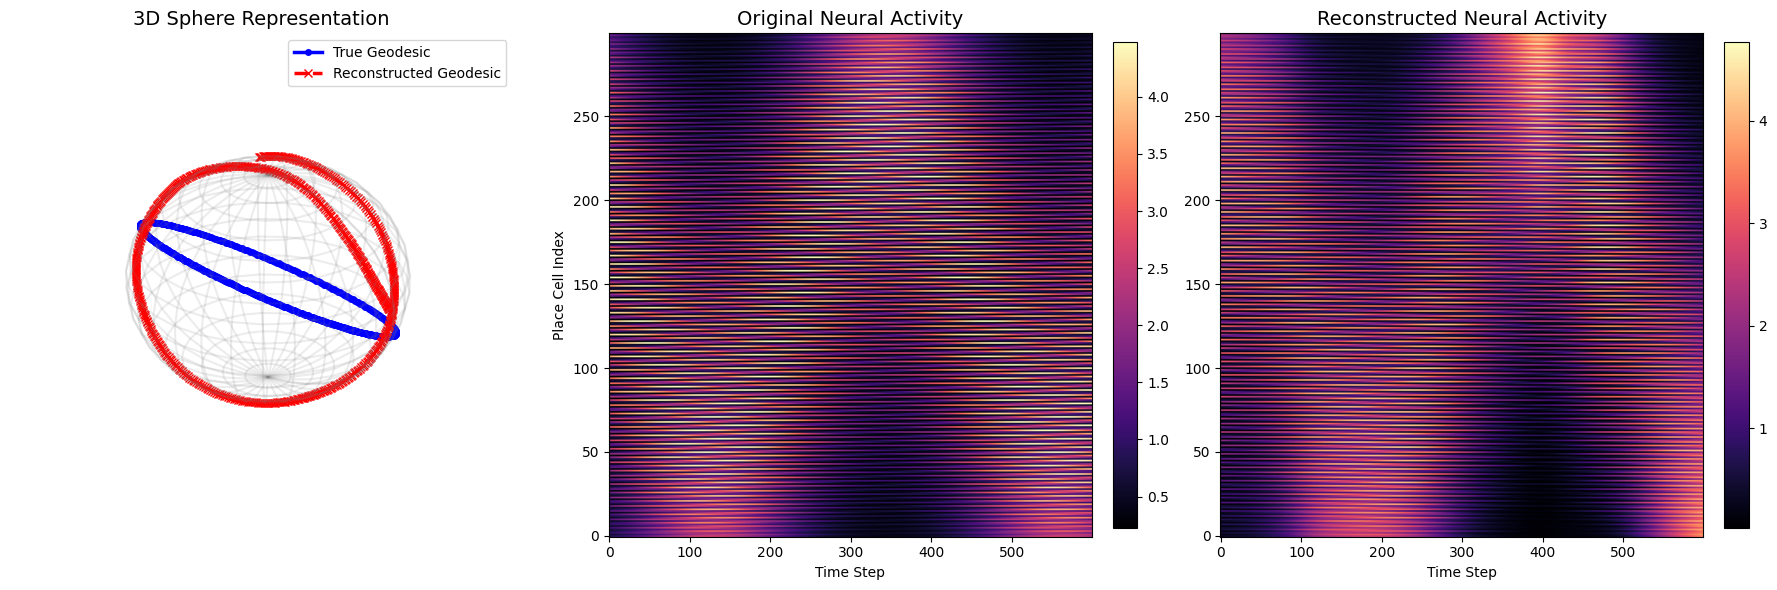

In [2]:
# Visualize the first whole heldout trial from the matched sphere-trials split.
test_traj_single = trajectories[HELDOUT_INDICES[0]]
test_act_single = y_heldout[0]

# Generate the plot
plot_test_reconstruction(params, test_traj_single, test_act_single, place_cells, DT)